### 라이브러리 설치 및 임포트

In [1]:
pip install nltk pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 필요 시 라이브러리 설치 (이미 설치되어 있다면 주석 처리하세요)
# !pip install pandas numpy nltk matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정 (그래프를 예쁘게 출력하기 위함)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# VADER 감성 사전 다운로드 (최초 1회만 실행됨)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

print("라이브러리 로드 및 VADER 준비 완료!")

라이브러리 로드 및 VADER 준비 완료!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ids/nltk_data...


### 데이터 로드 및 전처리

In [3]:
# 데이터 경로 (프로젝트 루트 기준 ../data/)
DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

# 1. 리뷰 데이터 불러오기 (실제 파일명으로 변경하세요)
df = pd.read_csv(f'{DATA_DIR}museum_review.csv') 

# 임시 예시 코드로, 실제 df 변수에 데이터를 할당했다고 가정합니다.
# 텍스트가 없는 리뷰(65개) 결측치 처리: 빈 문자열로 채우기
df['text'] = df['text'].fillna('')

# 데이터 기본 정보 확인
print(f"총 리뷰 수: {len(df)}")
print(f"텍스트 결측치 처리 후 빈 텍스트 수: {(df['text'] == '').sum()}")

# 첫 3줄 예쁘게 출력
display(df.head(3))

총 리뷰 수: 4119
텍스트 결측치 처리 후 빈 텍스트 수: 65


,title,museum_id,stars,text,id
0,Louvre Museum,1001,2,I enjoyed watching it because there were many ...,1
1,Louvre Museum,1001,2,One of the most famous and important museums o...,2
2,Louvre Museum,1001,2,The mob of humanity coursing upstream like spa...,3


### VADER 감성 점수 추출
VADER를 이용해 감성 점수(-1 ~ 1)를 뽑아내고 긍정/부정/중립을 분류합니다.

In [8]:
# 1. VADER Compound Score 추출 함수
def get_vader_compound(text):
    if not text.strip(): # 텍스트가 비어있으면 중립(0) 반환
        return 0.0
    return sia.polarity_scores(text)['compound']

# 2. 감성 점수 컬럼 생성
df['sentiment_score'] = df['text'].apply(get_vader_compound)

# 3. 감성 카테고리 분류 (기준: 0.05 이상 긍정, -0.05 이하 부정)
conditions = [
    (df['sentiment_score'] >= 0.05),
    (df['sentiment_score'] <= -0.05)
]
choices = ['Positive', 'Negative']
df['sentiment_category'] = np.select(conditions, choices, default='Neutral')

display(df[['stars', 'text', 'sentiment_score', 'sentiment_category']].head())

,stars,text,sentiment_score,sentiment_category
0,2,I enjoyed watching it because there were many ...,-0.9696,Negative
1,2,One of the most famous and important museums o...,-0.3041,Negative
2,2,The mob of humanity coursing upstream like spa...,0.8160,Positive
3,2,We had tickets for 10:00. We arrived early and...,0.7713,Positive
4,2,We visited this museum over the weekend and it...,-0.9780,Negative


### 가성비/가격 관련 키워드 필터링
프로젝트의 핵심인 '티켓 가격'과 관련된 리뷰만 식별해냅니다.

In [9]:
# 가격/가성비 관련 키워드 리스트
price_keywords = ['ticket', 'price', 'cost', 'expensive', 'money', 'worth', 'free', 'pay', 'charge', 'value']

def check_price_keywords(text):
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in price_keywords)

df['is_price_related'] = df['text'].apply(check_price_keywords)

print(f"가격 관련 언급이 있는 리뷰 수: {df['is_price_related'].sum()}개")
print(f"가격 관련 언급이 없는 리뷰 수: {(~df['is_price_related']).sum()}개")

# 완료된 데이터셋 저장 (필요 시)
df.to_csv(f'{OUTPUT_DIR}museum_reviews_sentiment_analyzed.csv', index=False, encoding='utf-8-sig')

가격 관련 언급이 있는 리뷰 수: 1834개
가격 관련 언급이 없는 리뷰 수: 2285개


### 📊 분석 1: 별점(Stars)과 VADER 감성 점수의 관계 시각화
별점은 높지만 감성 점수가 낮은 '모순된 리뷰' 분포를 확인합니다.

/var/folders/04/kdlrrf9j6znbqh2dchx5zh3m0000gn/T/ipykernel_97567/1043197964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stars', y='sentiment_score', data=df, palette='viridis')


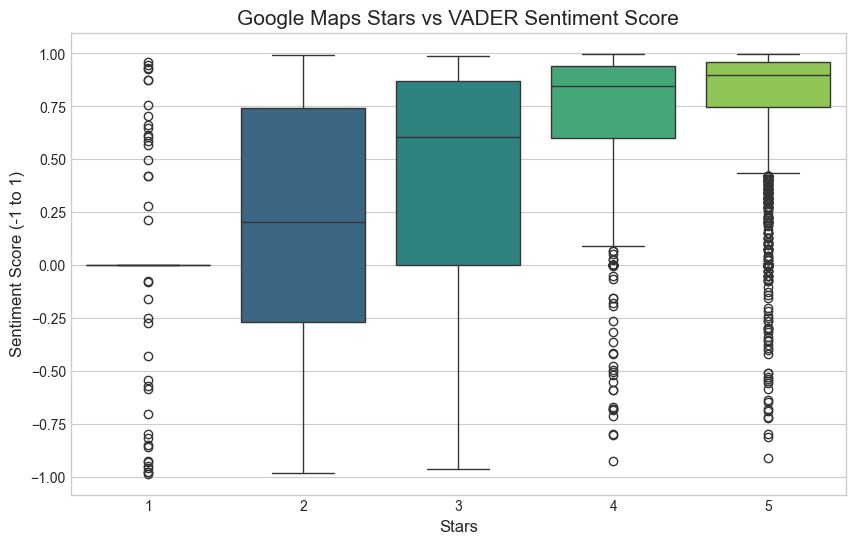

별점은 4점 이상이지만 텍스트 감성은 부정적인 리뷰 수: 73개


In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='stars', y='sentiment_score', data=df, palette='viridis')
plt.title('Google Maps Stars vs VADER Sentiment Score', fontsize=15)
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.show()

# 별점은 4~5점인데 감성 점수는 부정(-0.05 이하)인 리뷰 개수 확인
hidden_negatives = df[(df['stars'] >= 4) & (df['sentiment_score'] <= -0.05)]
print(f"별점은 4점 이상이지만 텍스트 감성은 부정적인 리뷰 수: {len(hidden_negatives)}개")

### 📊 분석 2: 일반 리뷰 vs 가격 관련 리뷰의 감성 비교
유료화 정책 설득을 위한 시각화 자료입니다.

/var/folders/04/kdlrrf9j6znbqh2dchx5zh3m0000gn/T/ipykernel_97567/2968582461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_price_related', y='sentiment_score', data=df, errorbar=None, palette='pastel')


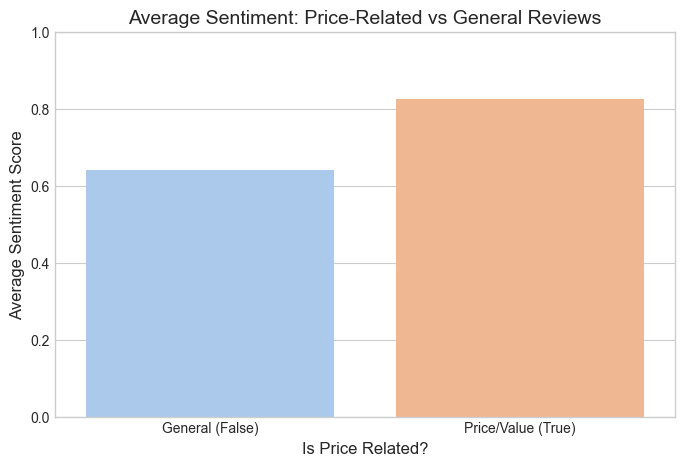

일반 리뷰 평균 감성 점수: 0.639
가격/가성비 관련 리뷰 평균 감성 점수: 0.826


In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x='is_price_related', y='sentiment_score', data=df, errorbar=None, palette='pastel')

plt.title('Average Sentiment: Price-Related vs General Reviews', fontsize=14)
plt.xlabel('Is Price Related?', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.xticks([0, 1], ['General (False)', 'Price/Value (True)'])
plt.ylim(0, 1) # 점수 범위에 따라 조정 가능
plt.show()

# 실제 평균 수치 출력
avg_general = df[df['is_price_related'] == False]['sentiment_score'].mean()
avg_price = df[df['is_price_related'] == True]['sentiment_score'].mean()
print(f"일반 리뷰 평균 감성 점수: {avg_general:.3f}")
print(f"가격/가성비 관련 리뷰 평균 감성 점수: {avg_price:.3f}")